In [ ]:
import sys

In [ ]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.transforms as transforms
import torch
from sklearn.model_selection import train_test_split

In [ ]:
import pickle

In [ ]:
from models.models import LeNet5, ResNet18
from lightning_modules.lightning_modules import LitLeNet5, LitResNet18
from visualization.filters import display_filters
from visualization.display import process_plot_image, display_metrics
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model, train_with_cv
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomDatasetWrapper
from utils.utils import load_targets, get_stat_metrics

In [ ]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)

In [ ]:
classification_mode="binary"

In [ ]:
task = {
    'binary': 2,
    'only_bad': 3,
    'all': 4
}

In [ ]:
num_classes = task[classification_mode]

In [ ]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [ ]:
# Try to load cached targets first
try:
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "rb") as f:
        targets = pickle.load(f)
except FileNotFoundError:
    targets = [t for _, t in aux_data]
    # Cache the targets for next time
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "wb") as f:
        pickle.dump(targets, f)

In [ ]:
# Assuming aux_data is a dataset object and targets are the labels
train_idx, val_idx, _, _ = train_test_split(
    range(len(aux_data)), targets, test_size=0.2, random_state=42
)

train_data = torch.utils.data.Subset(aux_data, train_idx)
val_data = torch.utils.data.Subset(aux_data, val_idx)

In [ ]:
data_module = CustomImageDataModule(
    train_dataset=train_data,
    val_dataset=val_data,
    batch_size=32,
    num_workers=12,
)

In [ ]:
model = LitResNet18(num_classes=num_classes, learning_rate=0.001, pretrained=True)

### Test train

In [ ]:
torch.set_float32_matmul_precision('medium')

In [ ]:
trainer_config = {
    "patience": 50,
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 5,
    "precision": 32,
    "n_steps": 5,
}

In [ ]:
model, val_metrics, cm = train_model(
    model=model,
    trainer_config=trainer_config,
    save_dir="logdir/LitResNet18-pretrained",
    data_module=data_module,
)

In [ ]:
df_onlybad = get_stat_metrics(
    parent_dir = 'logdir/LitResNet18-pretrained/only_bad',
    version = 0
)
display_metrics(
    csv_file = 'results/LitResNet18-pretrained/only_bad.csv',
    save = True

)

In [ ]:
# ConfusionMatrixDisplay(np.array(cm)).plot()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['notebook','grid'])

In [19]:
df = pd.read_csv('/mnt/g/My Drive/structure-loss-classification/results/LitResNet18-not-pretrained/all.csv')
df2 = pd.read_csv('/mnt/g/My Drive/structure-loss-classification/results/LitResNet18/all.csv')

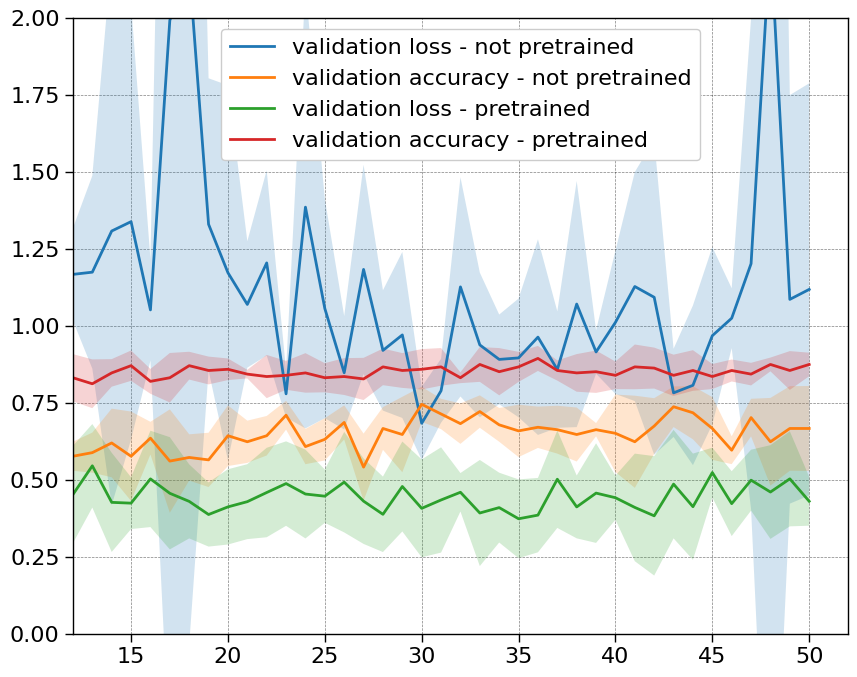

In [25]:
plt.figure(figsize=(10,8))

plt.plot(df.epoch, df.mean_val_loss, label='validation loss - not pretrained')
plt.plot(df.epoch, df.mean_val_accuracy, label='validation accuracy - not pretrained')

plt.fill_between(df.epoch, df.mean_val_loss+df.std_val_loss, df.mean_val_loss-df.std_val_loss, alpha=0.2)
plt.fill_between(df.epoch, df.mean_val_accuracy+df.std_val_accuracy, df.mean_val_accuracy-df.std_val_accuracy, alpha=0.2)
plt.ylim(0,2)
plt.xlim(12,52)

plt.plot(df2.epoch, df2.mean_val_loss, label='validation loss - pretrained')
plt.plot(df2.epoch, df2.mean_val_accuracy, label='validation accuracy - pretrained')

plt.fill_between(df2.epoch, df2.mean_val_loss+df2.std_val_loss, df2.mean_val_loss-df2.std_val_loss, alpha=0.2)
plt.fill_between(df2.epoch, df2.mean_val_accuracy+df2.std_val_accuracy, df2.mean_val_accuracy-df2.std_val_accuracy, alpha=0.2)

plt.legend()

In [27]:
[max(df2.mean_val_accuracy), max(df.mean_val_accuracy)]

[0.8941176533699036, 0.7450980544090271]